Import libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load CIFAR-10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Original training data:", x_train.shape)
print("Original testing data:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 552s 3us/step
Original training data: (50000, 32, 32, 3)
Original testing data: (10000, 32, 32, 3)


Using only 4,000 images

In [ ]:
x = np.concatenate((x_train, x_test))
y = np.concatenate((y_train, y_test))

x = x[:4000]
y = y[:4000]

print("Images:", x.shape)
print("Labels:", y.shape)

Images: (4000, 32, 32, 3)
Labels: (4000, 1)


Split into training and testing

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

Training: (3200, 32, 32, 3)
Testing: (800, 32, 32, 3)


CIFAR-10 class names

In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

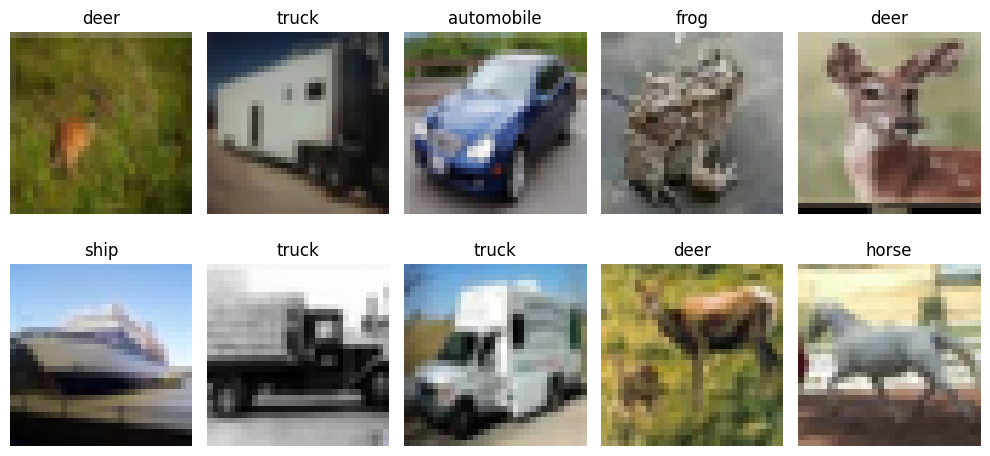

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

print(x_train.shape)
print(x_test.shape)

(3200, 224, 224, 3)
(800, 224, 224, 3)


VGG16 model

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

vgg16_model = Model(inputs=base_model.input, outputs=predictions)

vgg16_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
start_time = time.time()

vgg_history = vgg16_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

vgg_time = time.time() - start_time

print("VGG16 Training Time:", vgg_time, "seconds")

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 192ms/step - accuracy: 0.4997 - loss: 1.7020 - val_accuracy: 0.6031 - val_loss: 1.2125
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.7240 - loss: 0.7966 - val_accuracy: 0.6594 - val_loss: 0.9418
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step - accuracy: 0.8090 - loss: 0.5660 - val_accuracy: 0.6625 - val_loss: 0.9793
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.8573 - loss: 0.4275 - val_accuracy: 0.6969 - val_loss: 0.8985
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 213ms/step - accuracy: 0.8986 - loss: 0.3261 - val_accuracy: 0.7000 - val_loss: 0.8856
VGG16 Training Time: 106.9942615032196 seconds


In [ ]:
vgg_loss, vgg_accuracy = vgg16_model.evaluate(
    x_test,
    y_test
)

print("VGG16 Test Accuracy:", vgg_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.7325 - loss: 0.8542
VGG16 Test Accuracy: 0.7325000166893005


ResNet50 Model

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
start_time = time.time()

resnet_history = resnet_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

resnet_time = time.time() - start_time

print("ResNet50 Training Time:", resnet_time, "seconds")

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.6722 - loss: 0.9700 - val_accuracy: 0.7594 - val_loss: 0.6926
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.8444 - loss: 0.4615 - val_accuracy: 0.7688 - val_loss: 0.6799
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.8979 - loss: 0.3110 - val_accuracy: 0.8062 - val_loss: 0.5916
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9326 - loss: 0.2264 - val_accuracy: 0.7969 - val_loss: 0.5810
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9615 - loss: 0.1485 - val_accuracy: 0.8125 - val_loss: 0.5764
ResNet50 Training Time: 72.16439890861511 seconds


In [ ]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    x_test,
    y_test
)

print("ResNet50 Test Accuracy:", resnet_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.7837 - loss: 0.6381
ResNet50 Test Accuracy: 0.7837499976158142


Compare the models

In [ ]:
print("MODEL PERFORMANCE")
print("VGG16 Accuracy   :", vgg_accuracy)
print("ResNet50 Accuracy:", resnet_accuracy)

print("\nTRAINING TIME")
print("VGG16 Training Time   :", vgg_time, "seconds")
print("ResNet50 Training Time:", resnet_time, "seconds")

MODEL PERFORMANCE
VGG16 Accuracy   : 0.7325000166893005
ResNet50 Accuracy: 0.7837499976158142

TRAINING TIME
VGG16 Training Time   : 106.9942615032196 seconds
ResNet50 Training Time: 72.16439890861511 seconds


Accuracy graph

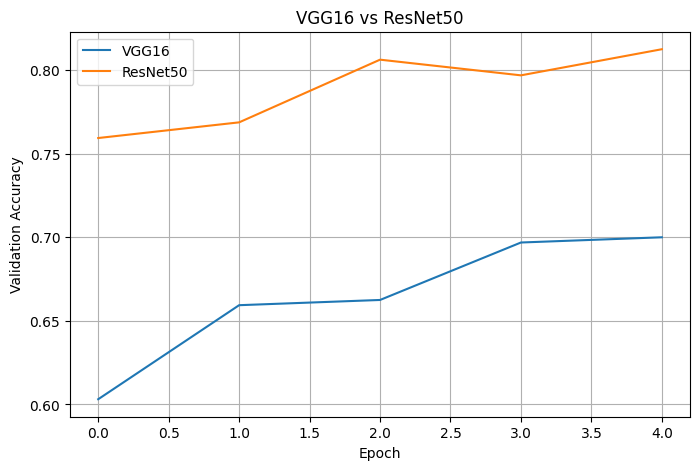

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(vgg_history.history['val_accuracy'], label='VGG16')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('VGG16 vs ResNet50')
plt.legend()
plt.grid()
plt.show()

Accuracy graph

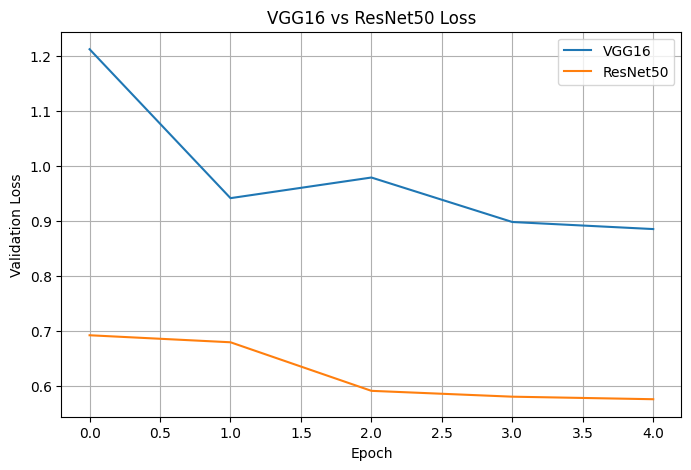

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(vgg_history.history['val_loss'], label='VGG16')
plt.plot(resnet_history.history['val_loss'], label='ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('VGG16 vs ResNet50 Loss')
plt.legend()
plt.grid()
plt.show()